<a href="https://colab.research.google.com/github/ant-jan/text-networks-workshop-26/blob/main/notebooks/text_networks_workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Derived Network Analysis Workshop

This workbook introduces network analysis from text using *Alice’s Adventures in Wonderland* as a hands-on example. The structure of this workshop is inspired by Thomas T. Hills’ *Behavioral Network Science: Language, Mind, and Society* (https://thomasthills.github.io/BehavioralNetworkScience.html).

We will turn a literary text into a character network, then use the same logic to think about psychological text data, such as emotions, symptoms, themes, or concepts in open-ended responses.

## Workshop workflow

1. Setup
2. Load the text
3. Clean and inspect the text
4. Split the book into chapters
5. Identify character appearances
6. Create an affiliation matrix
7. Build a bipartite network
8. Project it into a one-mode character network
9. Threshold the network
10. Edgelists and uploading edgelists
11. Adjacency matrix
12. Network measures
13. Community detection
14. Random graphs
15. Reflection


# 1. Setup

First, we prepare the R environment.

We clear the workspace, install any missing packages, and load the packages we will use throughout the workshop.

In [32]:
# ---- Setup ----

rm(list = ls())

packages <- c(
  "igraph",
  "dplyr",
  "tidyr",
  "tibble",
  "stringr"
)

installed <- rownames(installed.packages())

for (pkg in packages) {
  if (!pkg %in% installed) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}

library(igraph)
library(dplyr)
library(tidyr)
library(tibble)
library(stringr)

# Make all plots larger
options(repr.plot.width = 12, repr.plot.height = 9)

# 2. Load the text

We will read the text file directly from GitHub.

The file is a plain-text version of *Alice’s Adventures in Wonderland* from Project Gutenberg. At this stage, it still includes Project Gutenberg header and footer material, so we will inspect it before cleaning.

In [33]:
# ---- Load Alice text from GitHub ----

alice_url <- "https://raw.githubusercontent.com/ant-jan/text-networks-workshop-26/main/data/raw/alice_in_wonderland.txt"

alice_raw <- readLines(alice_url, encoding = "UTF-8", warn = FALSE)

# Inspect the first 20 lines
writeLines(head(alice_raw, 40))

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”


# 3. Clean the text

The raw file includes Project Gutenberg metadata before and after the actual book.

Before analysing the text, we remove the header and footer so that our network is based only on the story.

In [34]:
# ---- Clean the text ----

# Start at the actual beginning of the story
start_line <- str_which(alice_raw, "^CHAPTER I\\.$")[1]

# End at "THE END"
end_line <- str_which(alice_raw, "^THE END$")[1]

# Keep only the story text, excluding "THE END"
alice_text <- alice_raw[start_line:(end_line - 1)]

# Remove illustration markers and empty lines
alice_text <- alice_text[!str_detect(alice_text, "^\\[Illustration\\]$")]
alice_text <- alice_text[str_trim(alice_text) != ""]

# Inspect the cleaned text
writeLines(head(alice_text, 2))
writeLines(tail(alice_text, 2))

CHAPTER I.
Down the Rabbit-Hole
their simple joys, remembering her own child-life, and the happy summer
days.


# 4. Split the book into chapters

Our unit of analysis will be the chapter.

Later, when two characters are connected in the network, it will mean that they appeared in the same chapter. This is a methodological choice: we could also use scenes, paragraphs, or fixed-size text windows.


In [35]:
# ---- Split the book into chapters ----

# Find chapter heading lines
chapter_lines <- str_which(alice_text, "^CHAPTER [IVXLC]+\\.$")

# Inspect chapter headings
alice_text[chapter_lines]

[1] "CHAPTER I."    "CHAPTER II."   "CHAPTER III."  "CHAPTER IV."  
 [5] "CHAPTER V."    "CHAPTER VI."   "CHAPTER VII."  "CHAPTER VIII."
 [9] "CHAPTER IX."   "CHAPTER X."    "CHAPTER XI."   "CHAPTER XII."

In [36]:
# ---- Create chapter-level dataset ----

chapter_starts <- chapter_lines
chapter_ends <- c(chapter_lines[-1] - 1, length(alice_text))

chapters <- tibble(
  chapter_id = paste0("chapter_", seq_along(chapter_starts)),
  chapter_title = alice_text[chapter_starts + 1],
  text = mapply(
    function(start, end) paste(alice_text[(start + 2):end], collapse = " "),
    chapter_starts,
    chapter_ends
  )
)

#print one row of the created tibble
chapters %>%
  slice(1)

chapter_id chapter_title       
1 chapter_1  Down the Rabbit-Hole
  text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

# 5. Identify character appearances

We now create a character dictionary: a list of characters and the words or phrases we will search for in each chapter.

This step matters because the network depends on our coding choices. For example, should "Rabbit" count as "White Rabbit"? Should "Cat" count as "Cheshire Cat"? These are interpretive decisions.

In [37]:
# ---- Character dictionary ----

characters <- tibble(
  character = c(
    "Alice",
    "White Rabbit",
    "Mouse",
    "Dodo",
    "Lory",
    "Eaglet",
    "Caterpillar",
    "Duchess",
    "Cheshire Cat",
    "Hatter",
    "March Hare",
    "Dormouse",
    "Queen of Hearts",
    "King of Hearts",
    "Gryphon",
    "Mock Turtle",
    "Knave of Hearts",
    "Cook",
    "Bill"
  ),
  pattern = c(
    "\\bAlice\\b",
    "White Rabbit|\\bRabbit\\b",
    "\\bMouse\\b",
    "\\bDodo\\b",
    "\\bLory\\b",
    "\\bEaglet\\b",
    "\\bCaterpillar\\b",
    "\\bDuchess\\b",
    "Cheshire Cat|\\bCat\\b",
    "\\bHatter\\b",
    "March Hare|\\bHare\\b",
    "\\bDormouse\\b",
    "Queen of Hearts|\\bQueen\\b",
    "King of Hearts|\\bKing\\b",
    "\\bGryphon\\b",
    "Mock Turtle",
    "Knave of Hearts|\\bKnave\\b",
    "\\bCook\\b",
    "\\bBill\\b"
  )
)

characters

character,pattern
<chr>,<chr>
Alice,\bAlice\b
White Rabbit,White Rabbit|\bRabbit\b
Mouse,\bMouse\b
Dodo,\bDodo\b
Lory,\bLory\b
Eaglet,\bEaglet\b
Caterpillar,\bCaterpillar\b
Duchess,\bDuchess\b
Cheshire Cat,Cheshire Cat|\bCat\b


In [38]:
# ---- Check character matches ----

character_hits <- expand_grid(
  chapter_id = chapters$chapter_id,
  character = characters$character
) %>%
  left_join(chapters, by = "chapter_id") %>%
  left_join(characters, by = "character") %>%
  mutate(
    n_matches = str_count(text, regex(pattern))
  )

character_hits %>%
  filter(n_matches > 0) %>%
  select(chapter_id, chapter_title, character, n_matches) %>%
  arrange(chapter_id, desc(n_matches))

chapter_id,chapter_title,character,n_matches
<chr>,<chr>,<chr>,<int>
chapter_1,Down the Rabbit-Hole,Alice,28
chapter_1,Down the Rabbit-Hole,White Rabbit,5
chapter_10,The Lobster Quadrille,Gryphon,31
chapter_10,The Lobster Quadrille,Alice,30
chapter_10,The Lobster Quadrille,Mock Turtle,28
chapter_10,The Lobster Quadrille,White Rabbit,1
chapter_10,The Lobster Quadrille,Caterpillar,1
chapter_11,Who Stole the Tarts?,King of Hearts,26
chapter_11,Who Stole the Tarts?,Hatter,20


In [39]:
# ---- Detect character appearances by chapter ----

character_chapter <- character_hits %>%
  filter(n_matches > 0) %>%
  select(chapter_id, chapter_title, character)

character_chapter

chapter_id,chapter_title,character
<chr>,<chr>,<chr>
chapter_1,Down the Rabbit-Hole,Alice
chapter_1,Down the Rabbit-Hole,White Rabbit
chapter_2,The Pool of Tears,Alice
chapter_2,The Pool of Tears,White Rabbit
chapter_2,The Pool of Tears,Mouse
chapter_2,The Pool of Tears,Dodo
chapter_2,The Pool of Tears,Lory
chapter_2,The Pool of Tears,Eaglet
chapter_2,The Pool of Tears,Duchess


# 6. Create an affiliation matrix

An affiliation matrix connects two kinds of entities.

Here, the rows are characters and the columns are chapters. A value of 1 means that the character appears in that chapter; a value of 0 means that they do not.

This matrix is the basis for building a bipartite character–chapter network.

In [40]:
# ---- Create affiliation matrix ----

affiliation_matrix <- character_chapter %>%
  mutate(appears = 1) %>%
  select(character, chapter_id, appears) %>%
  pivot_wider(
    names_from = chapter_id,
    values_from = appears,
    values_fill = 0
  ) %>%
  column_to_rownames("character") %>%
  as.matrix()

affiliation_matrix

# Check dimensions: characters x chapters
dim(affiliation_matrix)

,chapter_1,chapter_2,chapter_3,chapter_4,chapter_5,chapter_6,chapter_7,chapter_8,chapter_9,chapter_10,chapter_11,chapter_12
Alice,1,1,1,1,1,1,1,1,1,1,1,1
White Rabbit,1,1,0,1,0,0,0,1,0,1,1,1
Mouse,0,1,1,0,0,0,0,0,0,0,0,1
Dodo,0,1,1,0,0,0,0,0,0,0,0,0
Lory,0,1,1,0,0,0,0,0,0,0,0,0
Eaglet,0,1,1,0,0,0,0,0,0,0,0,0
Duchess,0,1,0,1,0,1,0,1,1,0,1,1
Bill,0,0,0,1,0,0,0,0,0,0,1,1
Caterpillar,0,0,0,0,1,0,0,0,0,1,0,0
Cheshire Cat,0,0,0,0,0,1,0,1,0,0,0,0


[1] 18 12

This matrix is the bridge between text and network analysis. It no longer contains the full text. Instead, it records whether each character appears in each chapter.

# 7. Build a bipartite (two-mode) network

We now turn the affiliation matrix into a bipartite network.

A bipartite network has two types of nodes. In this case, one type is characters and the other type is chapters.

In [41]:
# ---- Build bipartite network ----

# Create an igraph network from the affiliation matrix
bipartite_network <- igraph::graph_from_biadjacency_matrix(
  affiliation_matrix,
  weighted = TRUE
)

# Inspect the network
bipartite_network

IGRAPH e9ed977 UNWB 30 71 -- 
+ attr: type (v/l), name (v/c), weight (e/n)
+ edges from e9ed977 (vertex names):
 [1] Alice       --chapter_1 White Rabbit--chapter_1 Alice       --chapter_2
 [4] White Rabbit--chapter_2 Mouse       --chapter_2 Dodo        --chapter_2
 [7] Lory        --chapter_2 Eaglet      --chapter_2 Duchess     --chapter_2
[10] Alice       --chapter_3 Mouse       --chapter_3 Dodo        --chapter_3
[13] Lory        --chapter_3 Eaglet      --chapter_3 Alice       --chapter_4
[16] White Rabbit--chapter_4 Duchess     --chapter_4 Bill        --chapter_4
[19] Alice       --chapter_5 Caterpillar --chapter_5 Alice       --chapter_6
[22] Duchess     --chapter_6 Cheshire Cat--chapter_6 Hatter      --chapter_6
+ ... omitted several edges

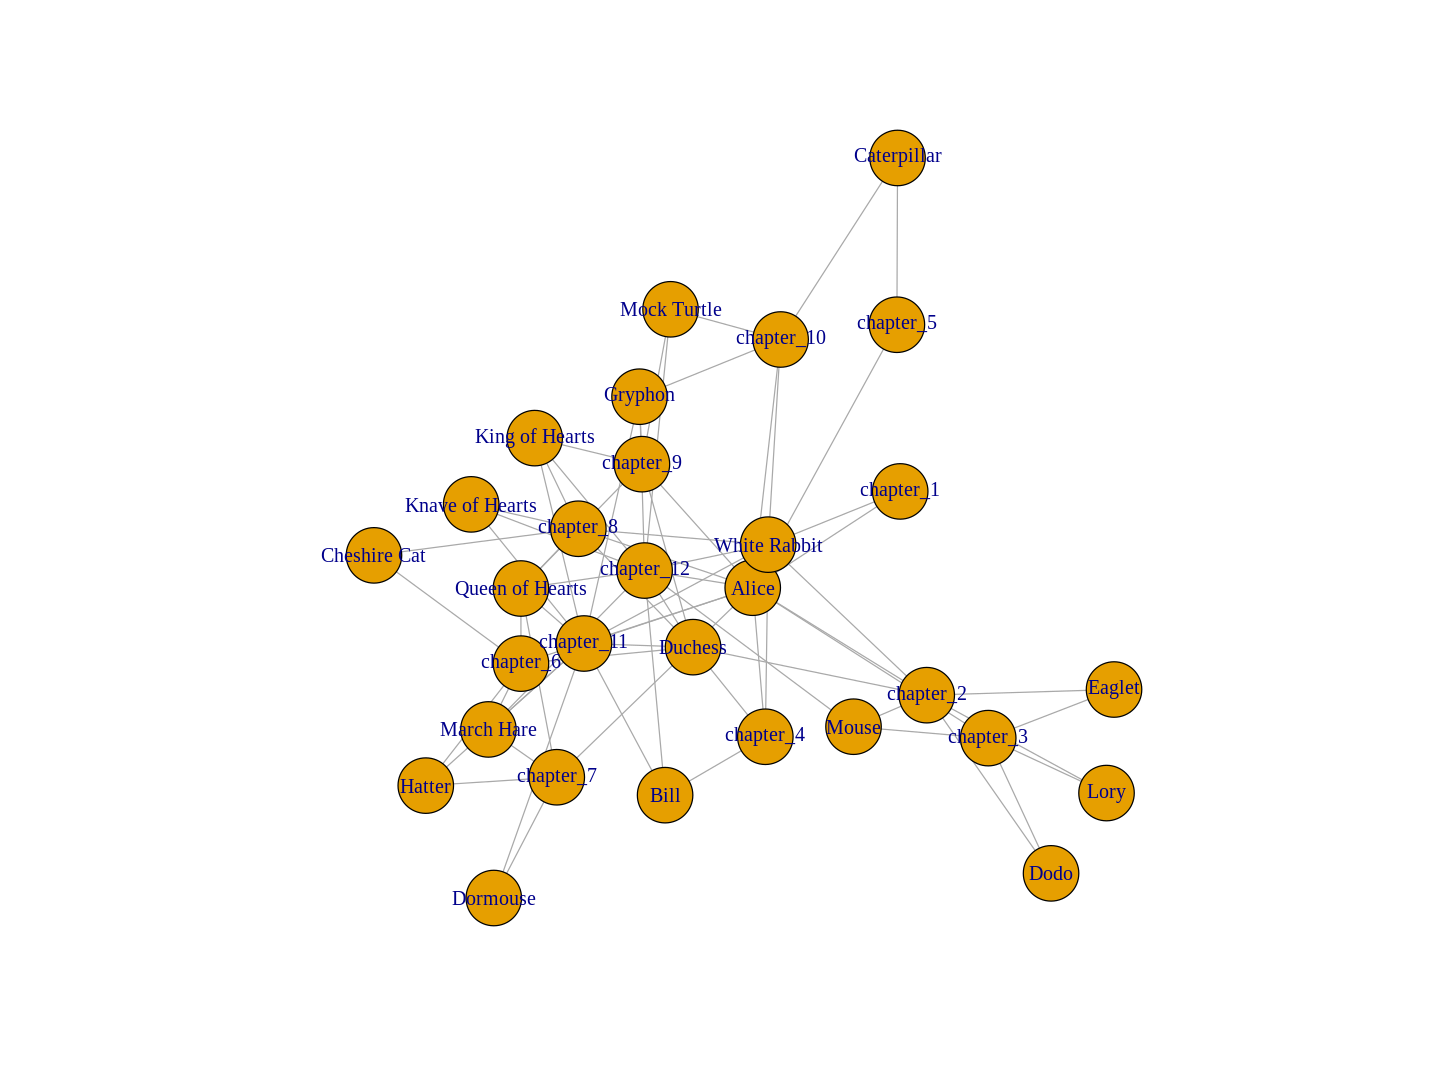

In [42]:
# ---- Visualize bipartite network ----

# R knows to plot igraph objects as networks
plot(bipartite_network)



This network contains two types of nodes: characters and chapters. It is therefore called a *bipartite network*.

At this stage, characters are not directly connected to other characters. Instead, characters are connected to the chapters in which they appear.

Ideally, we may want a network that contains only characters. In that network, two characters would share an edge if they appeared in the same chapter. This is called a one-mode, or monopartite, projection.

# 8. Project the network

We can project the bipartite network onto two one-mode networks.

One network represents the characters. In this network, two characters are connected if they appear in the same chapter.

The other network represents the chapters. In this network, two chapters are connected if they share characters.

For this workshop, we are mainly interested in the character network.

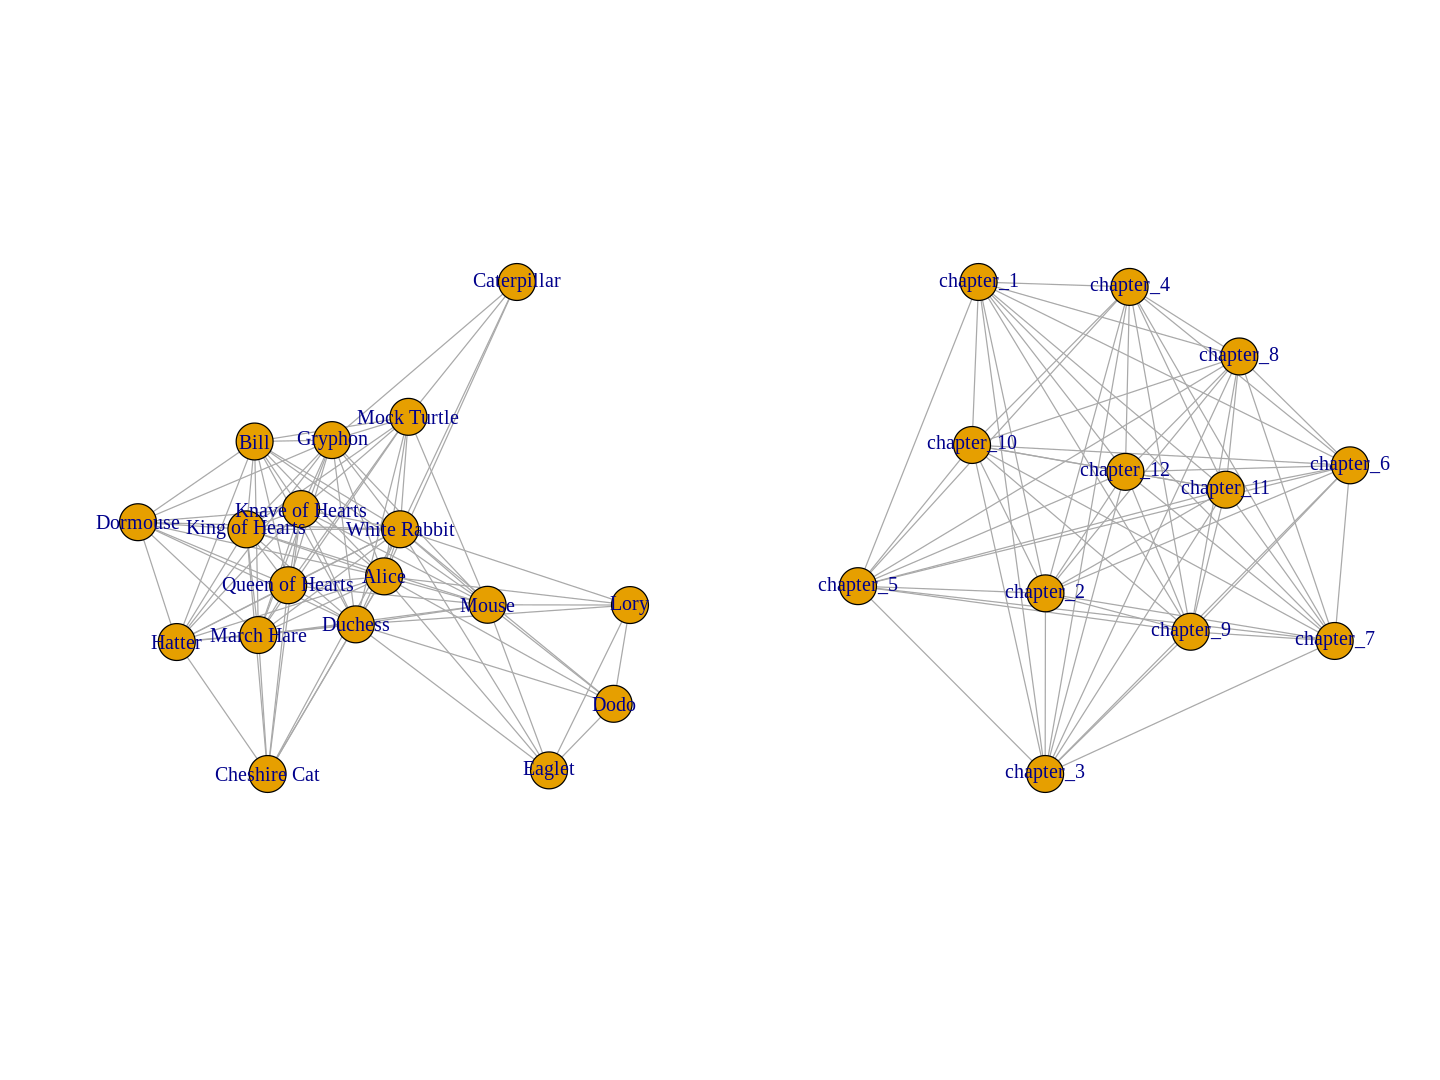

In [43]:
# ---- Project the bipartite network ----


# The function to project the network.
# multiplicity = TRUE creates weighted edges.
# In the character network, edge weights represent the number of chapters two characters share.

g.bp <- igraph::bipartite_projection(
  bipartite_network,
  multiplicity = TRUE
)

# Character network
# This should be the first projection because characters were the rows of the affiliation matrix.
character_network <- g.bp[[1]]

# Chapter network
# This is the second projection because chapters were the columns of the affiliation matrix.
chapter_network <- g.bp[[2]]

# This will create two plots in the window
par(mfrow = c(1, 2))

# Character network
plot(character_network)

# Chapter network
plot(chapter_network)

# Return to one plot per window
par(mfrow = c(1, 1))

The first plot is the character network. Each node is a character. An edge means that two characters appear in the same chapter.

The second plot is the chapter network. Each node is a chapter. An edge means that two chapters share one or more characters.

From this point on, we will mainly work with the character network.

# The igraph object

We can inspect the character network by printing the igraph object.

In [44]:
# ---- Inspect the character network ----

character_network

IGRAPH e78e6eb UNW- 18 101 -- 
+ attr: name (v/c), weight (e/n)
+ edges from e78e6eb (vertex names):
 [1] Alice       --White Rabbit    Alice       --Mouse          
 [3] Alice       --Dodo            Alice       --Lory           
 [5] Alice       --Eaglet          Alice       --Duchess        
 [7] Alice       --Bill            Alice       --Caterpillar    
 [9] Alice       --Cheshire Cat    Alice       --Hatter         
[11] Alice       --March Hare      Alice       --Queen of Hearts
[13] Alice       --Dormouse        Alice       --King of Hearts 
[15] Alice       --Knave of Hearts Alice       --Gryphon        
+ ... omitted several edges

The output tells us that this is an igraph object.

It also tells us how many nodes and edges the network has.

The nodes are now characters, not chapters. The edges are weighted. A higher edge weight means that two characters appear together in more chapters.

The output also lists graph attributes. For example, `name` means that the nodes have names, and `weight` means that the edges have numeric weights.

In [45]:
# ---- Check basic network features ----

# Count nodes
igraph::vcount(character_network)

# Count edges
igraph::ecount(character_network)

# Show the nodes
igraph::V(character_network)

# Show the edges
igraph::E(character_network)

# Get list of node names
igraph::V(character_network)$name

# Get list of edge weights
igraph::E(character_network)$weight

[1] 18

[1] 101

+ 18/18 vertices, named, from e78e6eb:
 [1] Alice           White Rabbit    Mouse           Dodo           
 [5] Lory            Eaglet          Duchess         Bill           
 [9] Caterpillar     Cheshire Cat    Hatter          March Hare     
[13] Queen of Hearts Dormouse        King of Hearts  Knave of Hearts
[17] Gryphon         Mock Turtle    

+ 101/101 edges from e78e6eb (vertex names):
 [1] Alice       --White Rabbit    Alice       --Mouse          
 [3] Alice       --Dodo            Alice       --Lory           
 [5] Alice       --Eaglet          Alice       --Duchess        
 [7] Alice       --Bill            Alice       --Caterpillar    
 [9] Alice       --Cheshire Cat    Alice       --Hatter         
[11] Alice       --March Hare      Alice       --Queen of Hearts
[13] Alice       --Dormouse        Alice       --King of Hearts 
[15] Alice       --Knave of Hearts Alice       --Gryphon        
[17] Alice       --Mock Turtle     White Rabbit--Mouse          
[19] White Rabbit--Dodo            White Rabbit--Lory           
+ ... omitted several edges

[1] "Alice"           "White Rabbit"    "Mouse"           "Dodo"           
 [5] "Lory"            "Eaglet"          "Duchess"         "Bill"           
 [9] "Caterpillar"     "Cheshire Cat"    "Hatter"          "March Hare"     
[13] "Queen of Hearts" "Dormouse"        "King of Hearts"  "Knave of Hearts"
[17] "Gryphon"         "Mock Turtle"

[1] 7 3 2 2 2 7 3 2 2 3 4 6 2 4 3 4 3 2 1 1 1 5 3 1 3 3 3 1 3 2 1 2 1 2 2 2 2
 [38] 1 1 1 1 1 1 1 2 2 1 2 1 1 3 2 2 3 5 4 3 3 2 1 1 2 2 1 2 2 2 1 1 1 1 1 2 1
 [75] 1 3 3 2 1 1 1 4 2 2 2 2 1 2 4 3 3 2 1 1 1 3 3 2 2 1 3

These checks help us understand what is stored inside the network object.

The most important parts are the node names and the edge weights. Together, they tell us which characters are connected and how strong each co-appearance tie is.

# 9. Threshold the network

The character network is weighted. The edge weight tells us how many chapters two characters share.

Sometimes the full projected network is too dense, because even one shared chapter creates an edge. Thresholding removes weaker edges so that we can focus on stronger co-appearance patterns.

Here, we remove edges below a chosen threshold. Then we set all remaining edge weights to 1, creating an unweighted version of the network.

In [46]:
# ---- Function for thresholding a network ----

# thresh_graph removes edges below a threshold value.
# It then sets all remaining edge weights to 1.
# This turns a weighted network into an unweighted network.

thresh_graph <- function(g, thresh) {

  # Remove edges with weight lower than the threshold
  gt <- igraph::delete_edges(
    g,
    igraph::E(g)[igraph::E(g)$weight < thresh]
  )

  # Set remaining edges to 1
  igraph::E(gt)$weight <- 1

  # Return thresholded graph
  return(gt)
}

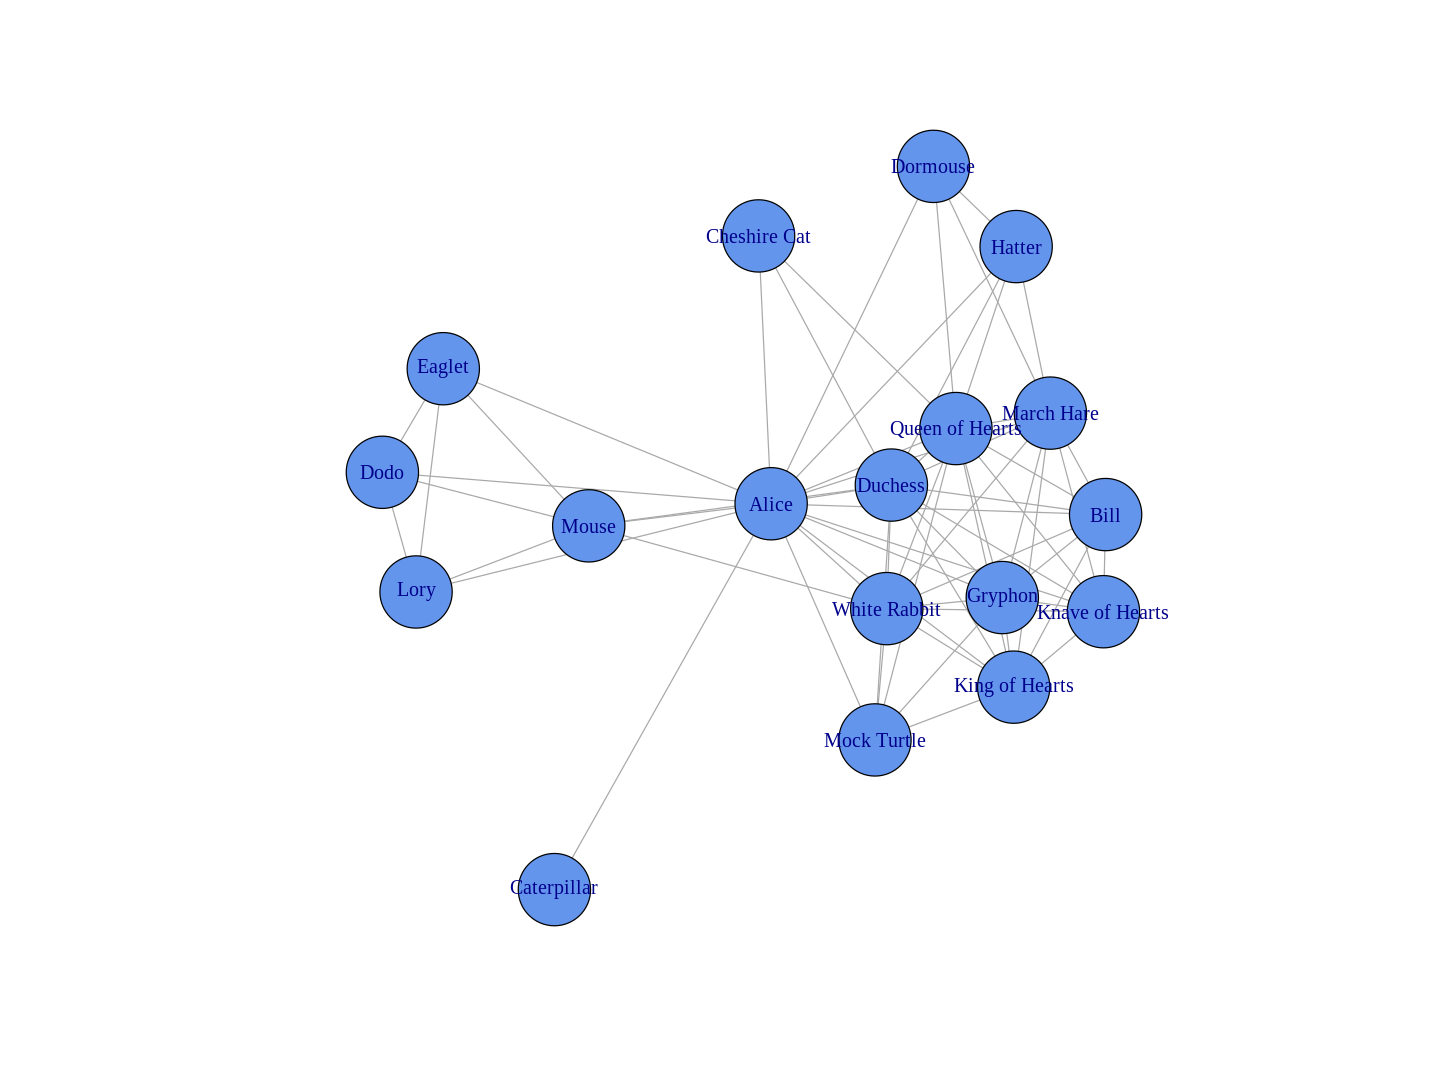

In [47]:
# ---- Threshold the character network ----

# Keep only character pairs who share at least 3 chapters
character_network_thresholded <- thresh_graph(character_network, 2)

# Plot thresholded network
par(mfrow = c(1, 1))

plot(
  character_network_thresholded,
  vertex.color = "cornflowerblue",
  vertex.size = 20,
  layout = igraph::layout_nicely
)

This thresholded network only keeps stronger co-appearance ties.

An edge now means that two characters appear together in at least 2 chapters. Character pairs connected by only one shared chapter have been removed from the plot.

Thresholding can make structure easier to see, but it is also an analytic choice.

In [48]:
# ---- Visualize different thresholds ----

# Find minimum and maximum edge weights
minweight <- min(igraph::E(character_network)$weight)
maxweight <- max(igraph::E(character_network)$weight)

minweight
maxweight

[1] 1

[1] 7

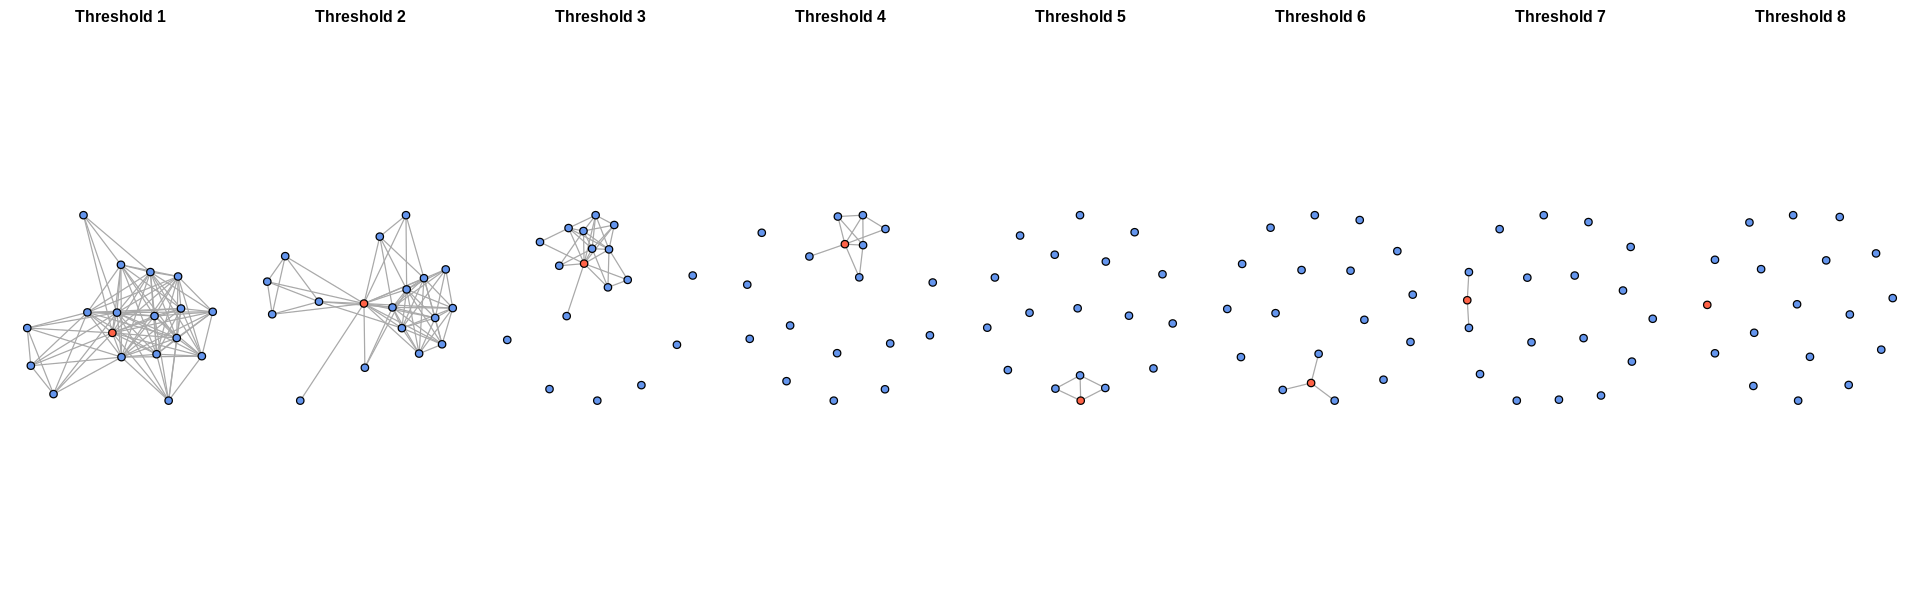

In [49]:
# ---- Plot thresholded networks across possible threshold values ----

options(repr.plot.width = 16, repr.plot.height = 5)

par(mfrow = c(1, maxweight - minweight + 2))
par(mar = c(1, 1, 2, 1))

for (i in minweight:(maxweight + 1)) {

  g <- thresh_graph(character_network, i)

  # Colour Alice differently from the other nodes
  node_colours <- ifelse(
    igraph::V(g)$name == "Alice",
    "tomato",
    "cornflowerblue"
  )

  plot(
    g,
    vertex.label = NA,
    vertex.color = node_colours,
    vertex.size = 8,
    layout = igraph::layout_nicely,
    main = paste("Threshold", i)
  )
}

As the threshold increases, weaker ties disappear.

A low threshold keeps more of the network but may look crowded. A high threshold reveals only the strongest relationships but may isolate or remove many characters from the main structure.

In [19]:
# Choose a threshold of 2 for next steps
threshold_value <- 2

character_network_thresholded <- thresh_graph(
  character_network,
  threshold_value
)

For the next steps, we choose a threshold that is readable but not too sparse. Following the logic of the seminar, we want a network that is not fully connected in an all-to-all way, but that still keeps the main characters connected enough to analyse.

For this Alice network, we use a threshold of 2, as it includes all characters, while making the network relatively sparse.

# 10. Edgelists and uploading edgelists

A network can also be represented as an edgelist.

An edgelist is a table where each row represents one edge. In this case, each row contains a pair of characters who are connected in the thresholded character network.

This is a common format for saving, sharing, and uploading network data.

In [50]:
# ---- Create an edgelist ----

edge_list <- igraph::as_edgelist(character_network_thresholded)

edge_list

Alice,White Rabbit
Alice,Mouse
Alice,Dodo
Alice,Lory
Alice,Eaglet
Alice,Duchess
Alice,Bill
Alice,Caterpillar
Alice,Cheshire Cat
Alice,Hatter
Alice,March Hare


Each row shows one connection between two characters.

Because we are using the thresholded network, these are only the character pairs that survived our chosen threshold.

# Save and reload an edgelist

We can save an edgelist as a CSV file. This is useful because many network analysis programs can read edgelists.

We can also read the edgelist back into R and reconstruct the network.

[1] "data.frame"

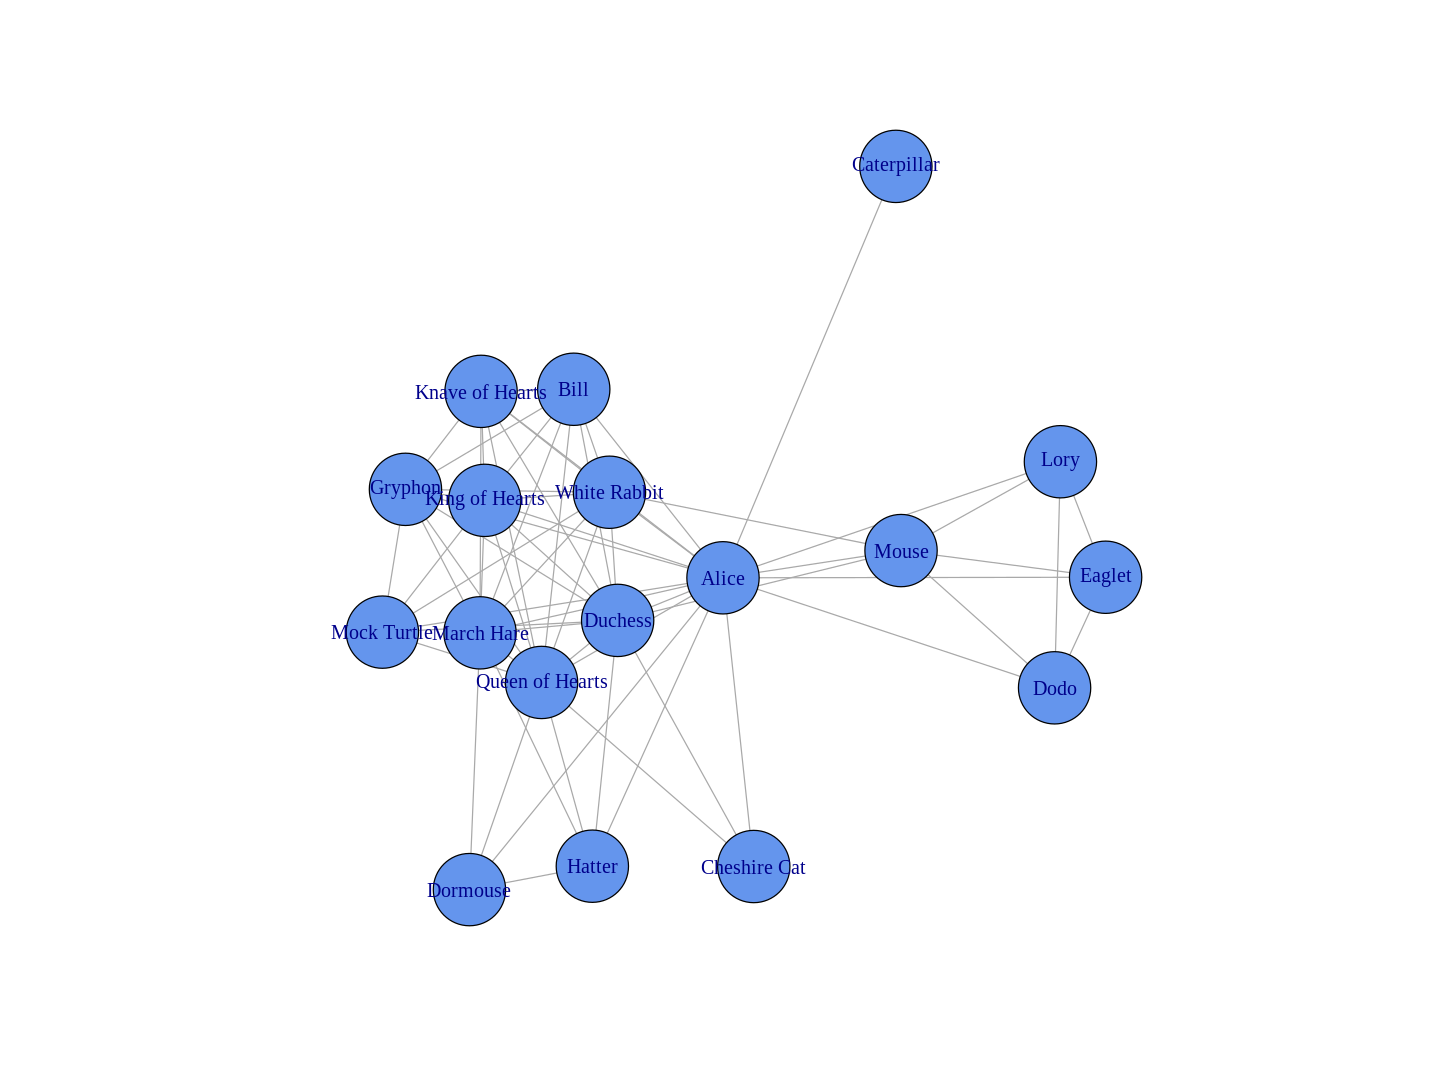

In [51]:
# ---- Save the edgelist ----

write.csv(
  edge_list,
  file = "alice_edgelist.csv",
  quote = FALSE,
  row.names = FALSE
)

# ---- Read the edgelist back into R ----

uploaded_edge_list <- read.csv("alice_edgelist.csv")


# Check the object type
class(uploaded_edge_list)

# ---- Recreate a network from the edgelist ----

# The edgelist is currently a data frame.
# We turn it into a matrix because graph_from_edgelist expects a matrix.

uploaded_edge_list <- as.matrix(uploaded_edge_list)

uploaded_graph <- igraph::graph_from_edgelist(
  uploaded_edge_list,
  directed = FALSE
)

# Plot the recreated network
par(mfrow = c(1, 1))

options(repr.plot.width = 12, repr.plot.height = 9)

plot(
  uploaded_graph,
  vertex.color = "cornflowerblue",
  vertex.size = 20,
  layout = igraph::layout_nicely
)

# 11. Adjacency matrix

A network can also be represented as an adjacency matrix.

In an adjacency matrix, both the rows and columns are nodes. Here, the rows and columns are characters.

A value of 1 means that two characters are connected. A value of 0 means that they are not connected.

In [22]:
# ---- Create adjacency matrix ----

# Get adjacency matrix from the thresholded character network.
# sparse = FALSE makes the matrix easier to inspect because it shows the zeros.

adjacency_matrix <- igraph::as_adjacency_matrix(
  character_network_thresholded,
  sparse = FALSE
)

adjacency_matrix

,Alice,White Rabbit,Mouse,Dodo,Lory,Eaglet,Duchess,Bill,Caterpillar,Cheshire Cat,Hatter,March Hare,Queen of Hearts,Dormouse,King of Hearts,Knave of Hearts,Gryphon,Mock Turtle
Alice,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
White Rabbit,1,0,1,0,0,0,1,1,0,0,0,1,1,0,1,1,1,1
Mouse,1,1,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0
Dodo,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
Lory,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
Eaglet,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
Duchess,1,1,1,0,0,0,0,1,0,1,1,1,1,0,1,1,1,1
Bill,1,1,0,0,0,0,1,0,0,0,0,1,1,0,1,1,1,0
Caterpillar,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Cheshire Cat,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0


This matrix contains the same network information as the plot, but in table form.

Each row and column is a character. If two characters are connected, the cell has a value of 1. If they are not connected, the cell has a value of 0.

# Save and reload an adjacency matrix

We can save the adjacency matrix as a CSV file.

This is useful because some network programs, and some statistical workflows, use adjacency matrices instead of edgelists.

In [52]:
# ---- Save adjacency matrix ----

# In Colab, this saves the file to the temporary runtime.
# It does not automatically save the file back to GitHub.

write.csv(
  adjacency_matrix,
  file = "alice_adjacency_matrix.csv",
  quote = FALSE
)

# Check that the file exists
file.exists("alice_adjacency_matrix.csv")

# ---- Read adjacency matrix back into R ----

# row.names = 1 tells R that the first column contains the character names.

uploaded_adjacency_matrix <- read.csv(
  "alice_adjacency_matrix.csv",
  header = TRUE,
  row.names = 1
)

# Check the object type
class(uploaded_adjacency_matrix)

# ---- Recreate a network from the adjacency matrix ----

# The uploaded adjacency matrix is currently a data frame.
# We turn it into a matrix so igraph can use it.

uploaded_adjacency_matrix <- as.matrix(uploaded_adjacency_matrix)

uploaded_graph_from_matrix <- igraph::graph_from_adjacency_matrix(
  uploaded_adjacency_matrix,
  mode = "undirected"
)

# Plot the recreated network
par(mfrow = c(1, 1))

plot(
  uploaded_graph_from_matrix,
  vertex.color = "white",
  vertex.size = 20,
  layout = igraph::layout_nicely
)

ERROR: Error in eval(expr, p): object 'adjacency_matrix' not found


This network was reconstructed from the saved adjacency matrix.

This shows that the same network can be stored in different formats. An edgelist stores the network as pairs of connected nodes. An adjacency matrix stores the network as a node-by-node table.

Both formats can be saved, reloaded, and turned back into an igraph object.

# 12. Network metrics

Now that we have a character network, we can calculate basic network measures.

These measures describe the overall structure of the network and the position of individual characters within it.

## Density

Density asks: **how connected is the whole network?**

It is the proportion of all possible edges that are actually present.

For an undirected network:

$$
\rho = \frac{m}{n(n-1)/2} = \frac{2m}{n(n-1)}
$$

where *m* is the number of observed edges and *n* is the number of nodes.

Density is a **network-level** measure. It describes the whole network, not an individual character.

In [53]:
# ---- Density ----

# Number of nodes in the thresholded character network
n_nodes <- igraph::vcount(character_network_thresholded)

# Number of observed edges
n_edges <- igraph::ecount(character_network_thresholded)

# Number of possible edges in an undirected network
possible_edges <- n_nodes * (n_nodes - 1) / 2

# Density calculated by igraph
density_igraph <- igraph::edge_density(character_network_thresholded)

# Density calculated manually
density_manual <- n_edges / possible_edges

# Put results in a small table
density_summary <- data.frame(
  nodes = n_nodes,
  observed_edges = n_edges,
  possible_edges = possible_edges,
  density_igraph = density_igraph,
  density_manual = density_manual
)

density_summary

nodes,observed_edges,possible_edges,density_igraph,density_manual
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18,66,153,0.4313725,0.4313725


The density of this network is about 0.43.

This means that about 43% of all possible character pairs are connected in the thresholded network. In other words, the network is not fully connected, but it is still fairly dense.

For this Alice network, this suggests that many characters share chapters with many other characters. One reason for this is that Alice appears across much of the story and links otherwise separate narrative episodes.

Density gives us a useful first description of the whole network. However, it does not tell us which characters are most central or whether the network contains smaller groups.

**Interpretation question**

What do you think would happen to density if we increased the threshold from 2 to 3?

## Degree

Degree asks: **how many other nodes is this node connected to?**

Degree is useful for identifying nodes that are broadly connected across the network. In a text-derived network, high degree may indicate that a character, concept, symptom, or emotion appears across many different contexts.

Degree is a node-level measure: each character gets their own degree value.

In [54]:
# ---- Degree ----

igraph::degree(character_network_thresholded)

Alice    White Rabbit           Mouse            Dodo            Lory 
             17              10               6               4               4 
         Eaglet         Duchess            Bill     Caterpillar    Cheshire Cat 
              4              12               8               1               3 
         Hatter      March Hare Queen of Hearts        Dormouse  King of Hearts 
              5              10              12               4               9 
Knave of Hearts         Gryphon     Mock Turtle 
              8               9               6

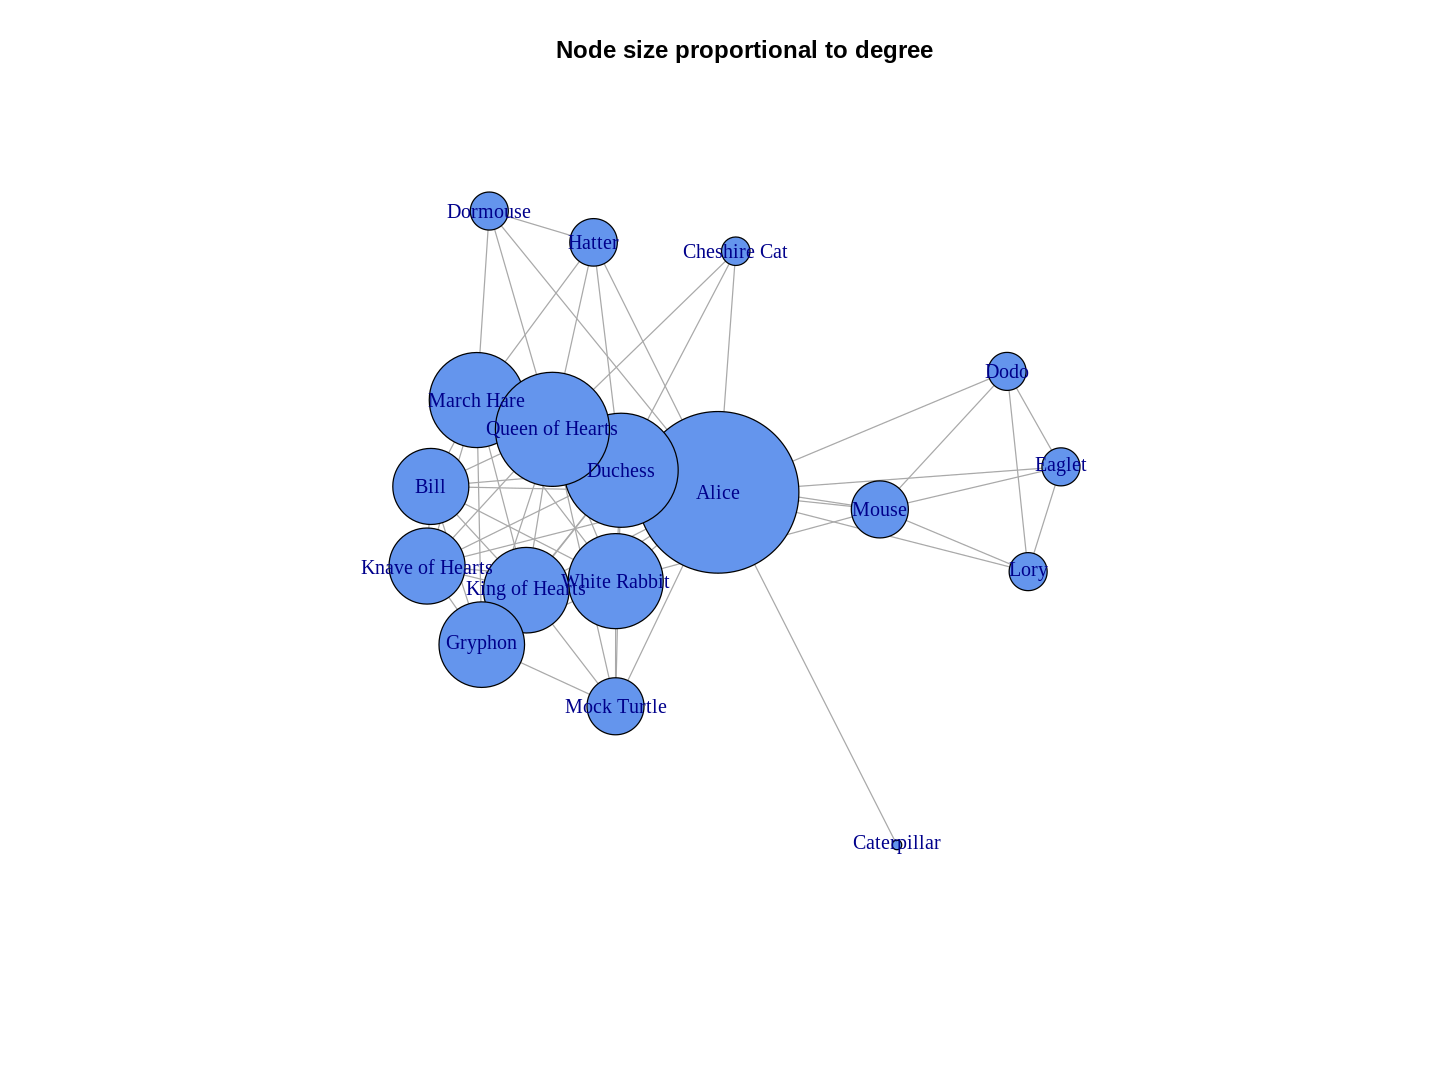

In [55]:
# ---- Plot node size proportional to degree ----

par(mfrow = c(1, 1))

plot(
  character_network_thresholded,
  vertex.size = igraph::degree(character_network_thresholded) * 3,
  vertex.color = "cornflowerblue",
  layout = igraph::layout_nicely,
  main = "Node size proportional to degree"
)

In this network, Alice has the highest degree. This is expected because Alice appears across much of the story and co-occurs with many different characters.

Other high-degree characters, such as the Duchess, the Queen of Hearts, the White Rabbit, and the March Hare, appear in parts of the story where several characters are present.

Degree is useful for identifying broadly connected characters, but it does not tell us whether those connections are strong or repeated. It only counts how many connections a character has after thresholding.

**Interpretation question**

Do you think Alice has high degree because she has above average number of friends in this world, or because she is the main character of the story?

## Clustering coefficient

The local clustering coefficient asks: **are a node's neighbours connected to each other?**

A character has high local clustering if the characters around them also tend to appear together.

![Local clustering coefficient]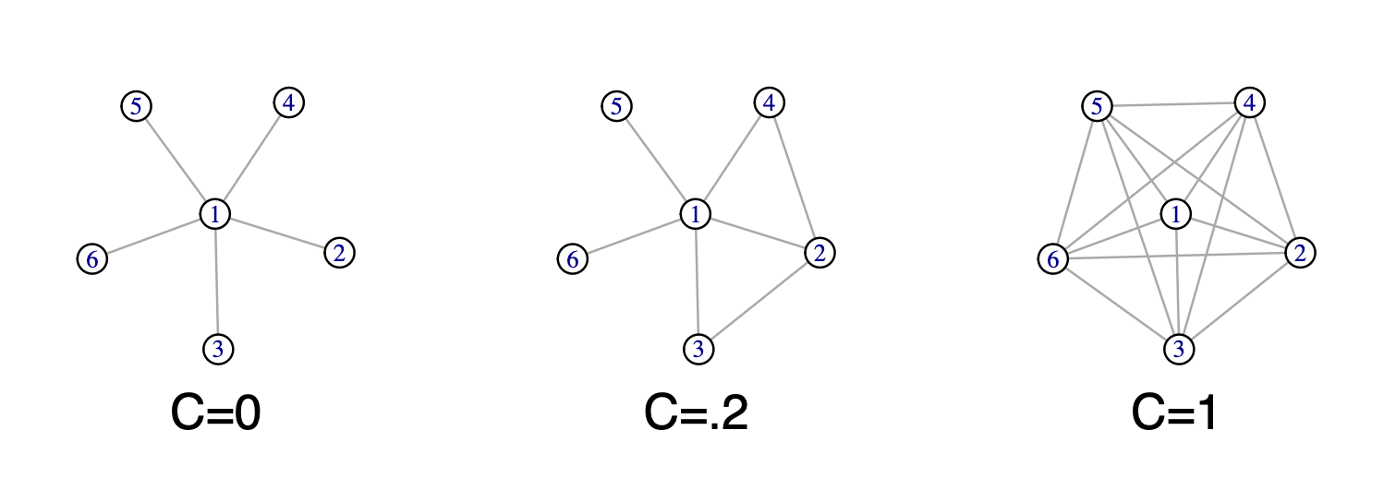

In [ ]:
# ---- Local clustering coefficient ----

igraph::transitivity(
  character_network_thresholded,
  type = "local"
)

Alice    White Rabbit           Mouse            Dodo            Lory 
      0.3602941       0.7777778       0.6000000       1.0000000       1.0000000 
         Eaglet         Duchess            Bill     Caterpillar    Cheshire Cat 
      1.0000000       0.6060606       1.0000000             NaN       1.0000000 
         Hatter      March Hare Queen of Hearts        Dormouse  King of Hearts 
      0.9000000       0.7555556       0.6212121       1.0000000       0.9166667 
Knave of Hearts         Gryphon     Mock Turtle 
      1.0000000       0.9166667       1.0000000

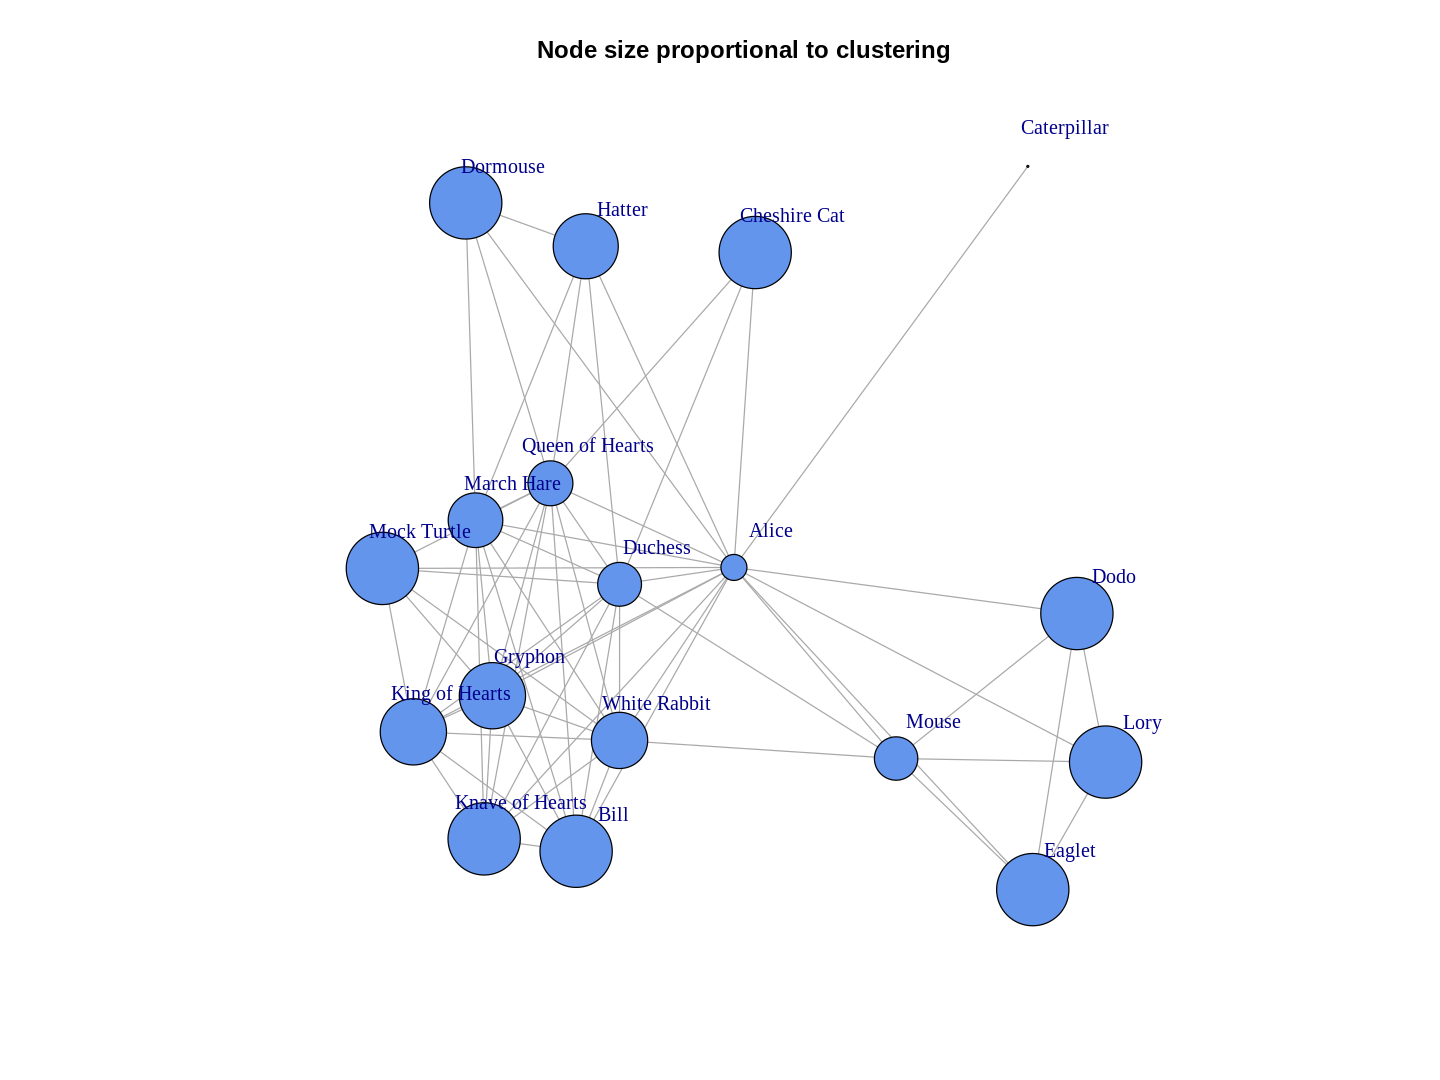

In [ ]:
# ---- Plot node size proportional to clustering coefficient ----

clustering_values <- igraph::transitivity(
  character_network_thresholded,
  type = "local"
)

# Replace NaN values with 0.
# NaN can occur when a node does not have enough neighbours for clustering to be defined.
clustering_values[is.nan(clustering_values)] <- 0

par(mfrow = c(1, 1))

plot(
  character_network_thresholded,
  vertex.size = clustering_values * 20,
  vertex.color = "cornflowerblue",
  vertex.label.dist = 2,
  layout = igraph::layout_nicely,
  main = "Node size proportional to clustering"
)

Larger nodes have higher local clustering.

Some less central characters have high clustering because they appear in tightly grouped episodes. Alice has lower clustering because she connects characters from different parts of the story who do not all appear together.

**Interpretation question**

Why might Alice have lower clustering than some characters who are much less central?

## Graph-level clustering

We can also describe clustering for the whole network.

Transitivity asks: **how often do connected triplets close into triangles?**

![Transitivity]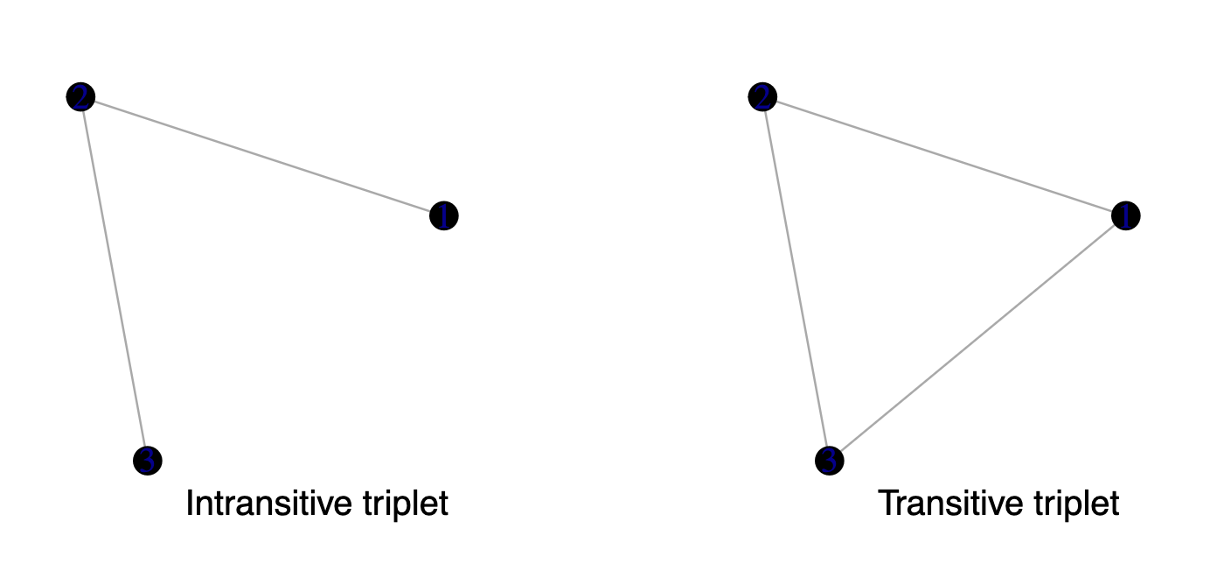

In [ ]:
# ---- Graph-level clustering ----

# Average local clustering coefficient
igraph::transitivity(
  character_network_thresholded,
  type = "localaverage"
)

# Global transitivity
igraph::transitivity(
  character_network_thresholded,
  type = "global"
)

[1] 0.850249

[1] 0.6889693

Both graph-level clustering values are fairly high. This suggests that character co-appearances often close into triangles rather than forming loose chains.

In this story, that likely reflects episode-based groups: characters who appear together in the same parts of the book.

**Interpretation question**

What kind of story structure could produce many closed triangles?

## Betweenness

Betweenness asks: **how often a node lies on shortest paths between other nodes?**


In this character network, a character with high betweenness may connect different parts of the network.

In [ ]:
# ---- Betweenness ----

igraph::betweenness(character_network_thresholded)

Alice    White Rabbit           Mouse            Dodo            Lory 
      61.000000        2.833333        3.000000        0.000000        0.000000 
         Eaglet         Duchess            Bill     Caterpillar    Cheshire Cat 
       0.000000        8.083333        0.000000        0.000000        0.000000 
         Hatter      March Hare Queen of Hearts        Dormouse  King of Hearts 
       0.250000        3.166667        7.666667        0.000000        0.500000 
Knave of Hearts         Gryphon     Mock Turtle 
       0.000000        0.500000        0.000000

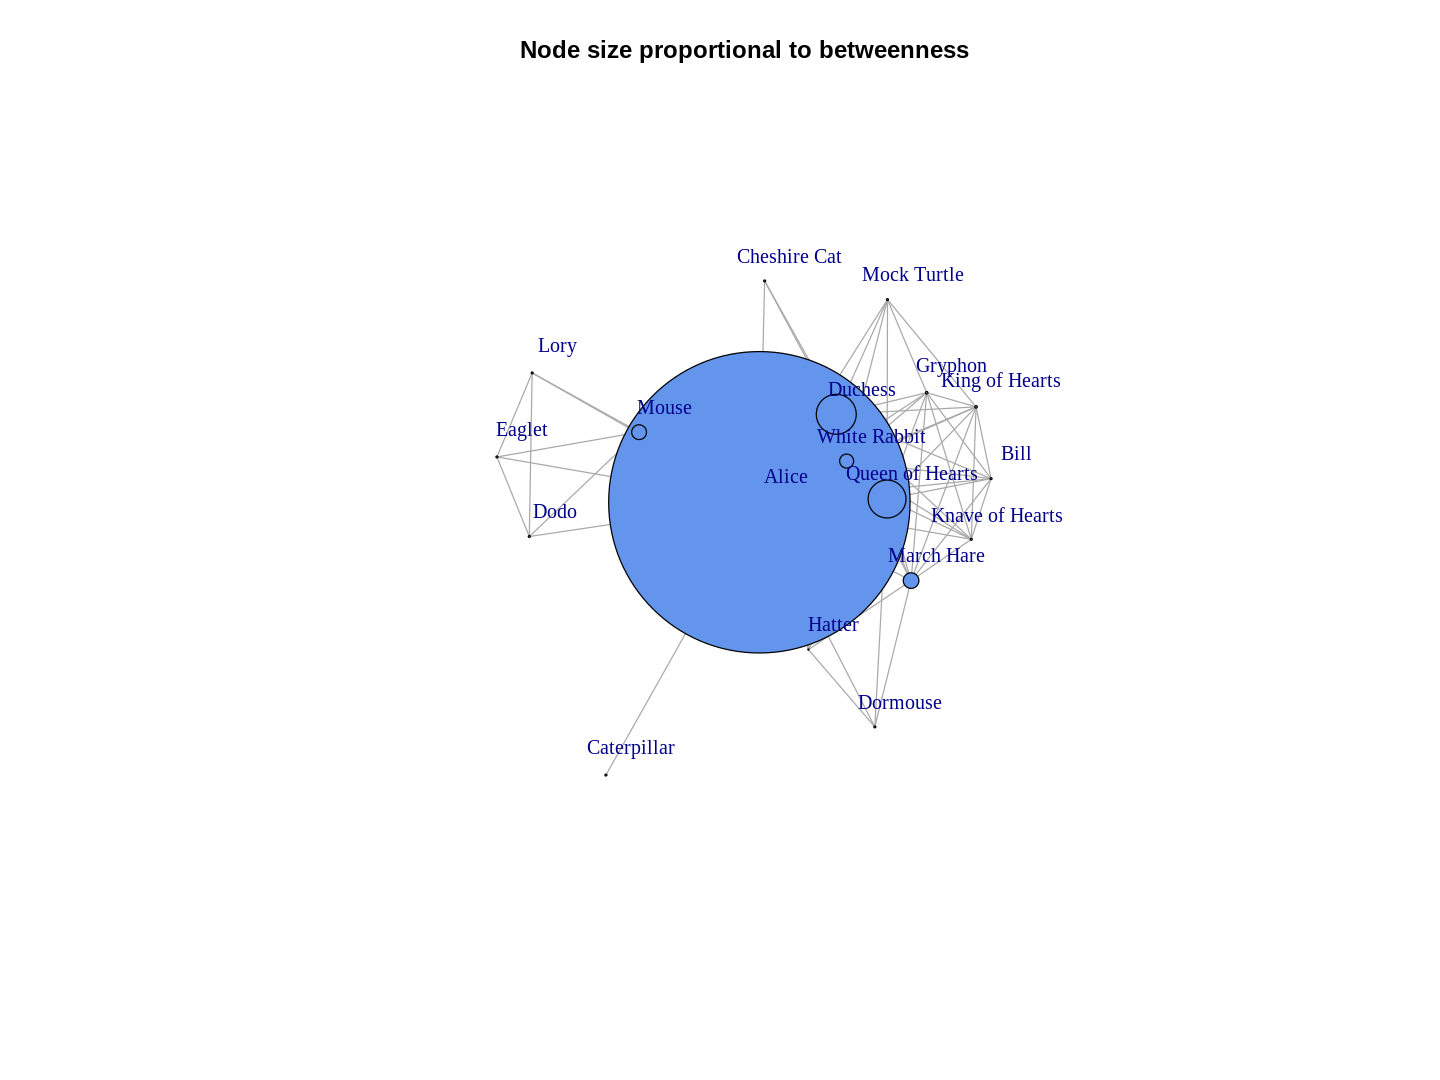

In [ ]:
# ---- Plot node size proportional to betweenness ----

betweenness_values <- igraph::betweenness(character_network_thresholded)

par(mfrow = c(1, 1))

plot(
  character_network_thresholded,
  vertex.size = betweenness_values * 2,
  vertex.color = "cornflowerblue",
  vertex.label.dist = 2,
  layout = igraph::layout_nicely,
  main = "Node size proportional to betweenness"
)

Alice has by far the highest betweenness in this network.

Here, this likely reflects her role as the protagonist: she appears across many parts of the story and links otherwise separate groups of characters.

In another kind of network, a node with very high betweenness might be important because it connects groups that would otherwise be separate.

**Interpretation question**

Imagine this was a network of emotions, symptoms, or themes instead of characters. What might it mean if one node had much higher betweenness than all the others?

## Closeness

Closeness asks: **how close is a node to all other nodes in the network?**

A node has high closeness if it can reach other nodes through only a few steps. Its basically the inverse of Average Shortest Path Lenght.

This measure is easiest to interpret when the network is connected.

In [ ]:
# ---- Closeness ----

igraph::closeness(
  character_network_thresholded,
  normalized = TRUE
)

Alice    White Rabbit           Mouse            Dodo            Lory 
      1.0000000       0.7083333       0.6071429       0.5666667       0.5666667 
         Eaglet         Duchess            Bill     Caterpillar    Cheshire Cat 
      0.5666667       0.7727273       0.6538462       0.5151515       0.5483871 
         Hatter      March Hare Queen of Hearts        Dormouse  King of Hearts 
      0.5862069       0.7083333       0.7727273       0.5666667       0.6800000 
Knave of Hearts         Gryphon     Mock Turtle 
      0.6538462       0.6800000       0.6071429

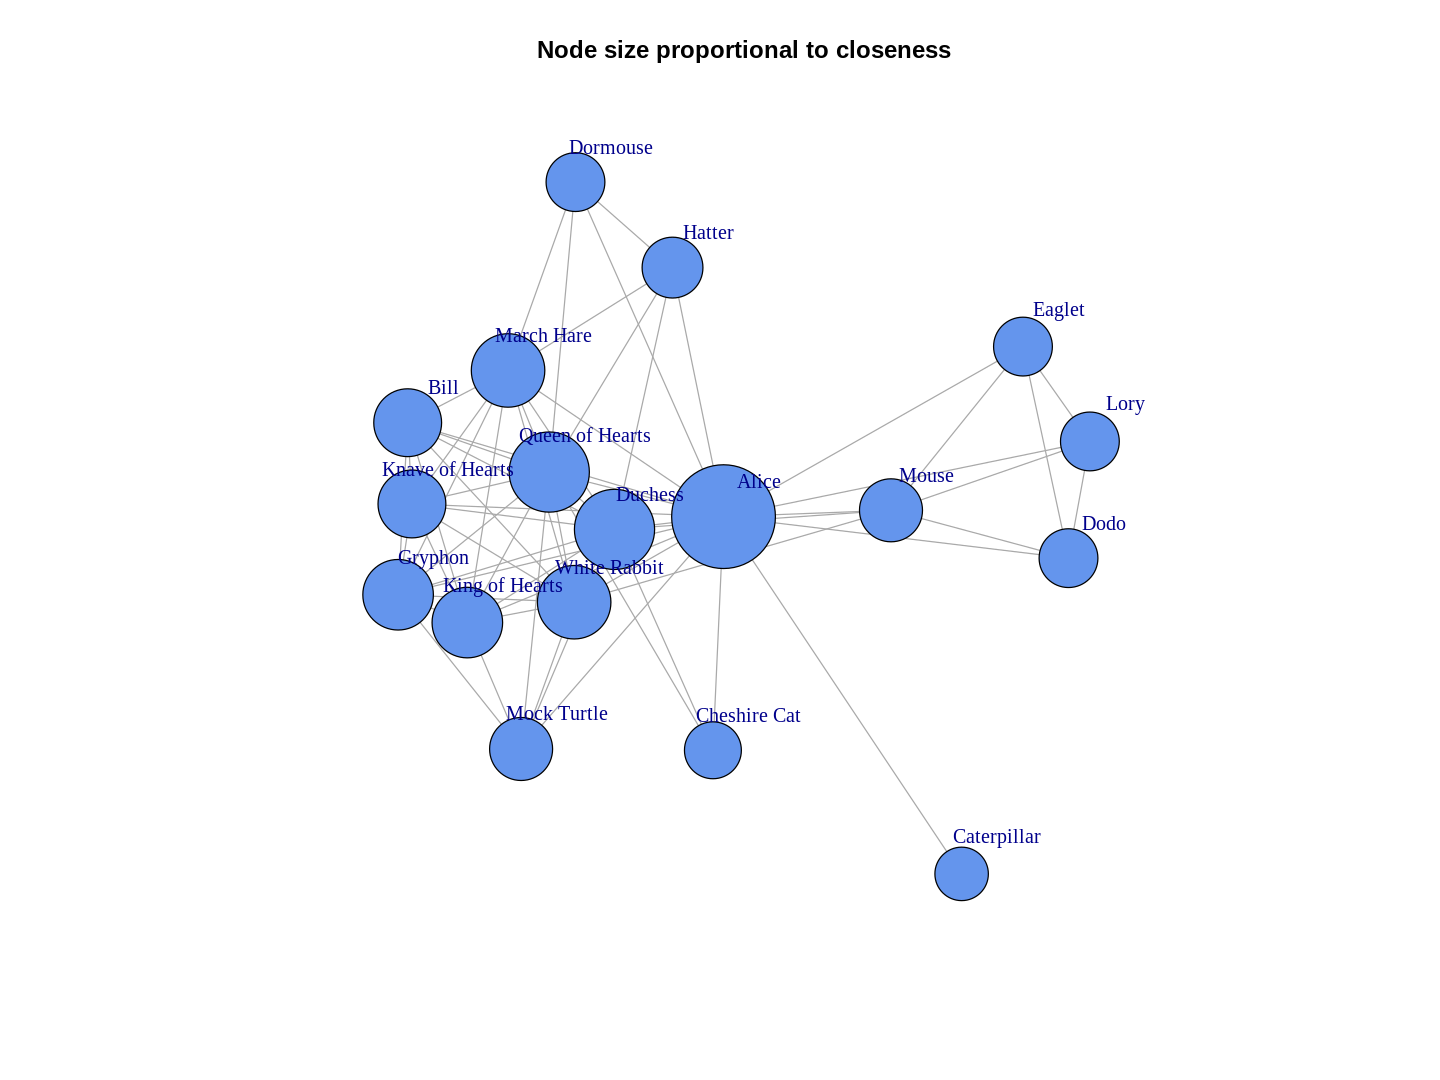

In [ ]:
# ---- Plot node size proportional to closeness ----

closeness_values <- igraph::closeness(
  character_network_thresholded,
  normalized = TRUE
)

par(mfrow = c(1, 1))

plot(
  character_network_thresholded,
  vertex.size = closeness_values * 30,
  vertex.color = "cornflowerblue",
  vertex.label.dist = 2,
  layout = igraph::layout_nicely,
  main = "Node size proportional to closeness"
)

Alice has the highest closeness because she is close to almost every other character in the network.

Other characters near the centre of the plot also have relatively high closeness. Characters on the edges, such as Caterpillar or some early animal characters, are farther from the rest of the network.

Closeness is useful when we care about how quickly something can reach the rest of the network.

**Interpretation question**

If this were a network of ideas or emotions, what might it mean for one node to be close to almost everything else?

## Eigenvector centrality

Eigenvector centrality asks whether a node is connected to other well-connected nodes.

A character can have high eigenvector centrality even if they are not the single most connected character, as long as they are connected to central parts of the network.

In [ ]:
# ---- Eigenvector centrality ----

eigenvector_values <- igraph::eigen_centrality(
  character_network_thresholded
)$vector

eigenvector_values

Alice    White Rabbit           Mouse            Dodo            Lory 
      1.0000000       0.8275655       0.3590885       0.1893579       0.1893579 
         Eaglet         Duchess            Bill     Caterpillar    Cheshire Cat 
      0.1893579       0.8998431       0.7364997       0.1089639       0.3048848 
         Hatter      March Hare Queen of Hearts        Dormouse  King of Hearts 
      0.4307106       0.8124532       0.8981930       0.3422944       0.7922824 
Knave of Hearts         Gryphon     Mock Turtle 
      0.7364997       0.7922824       0.5677199

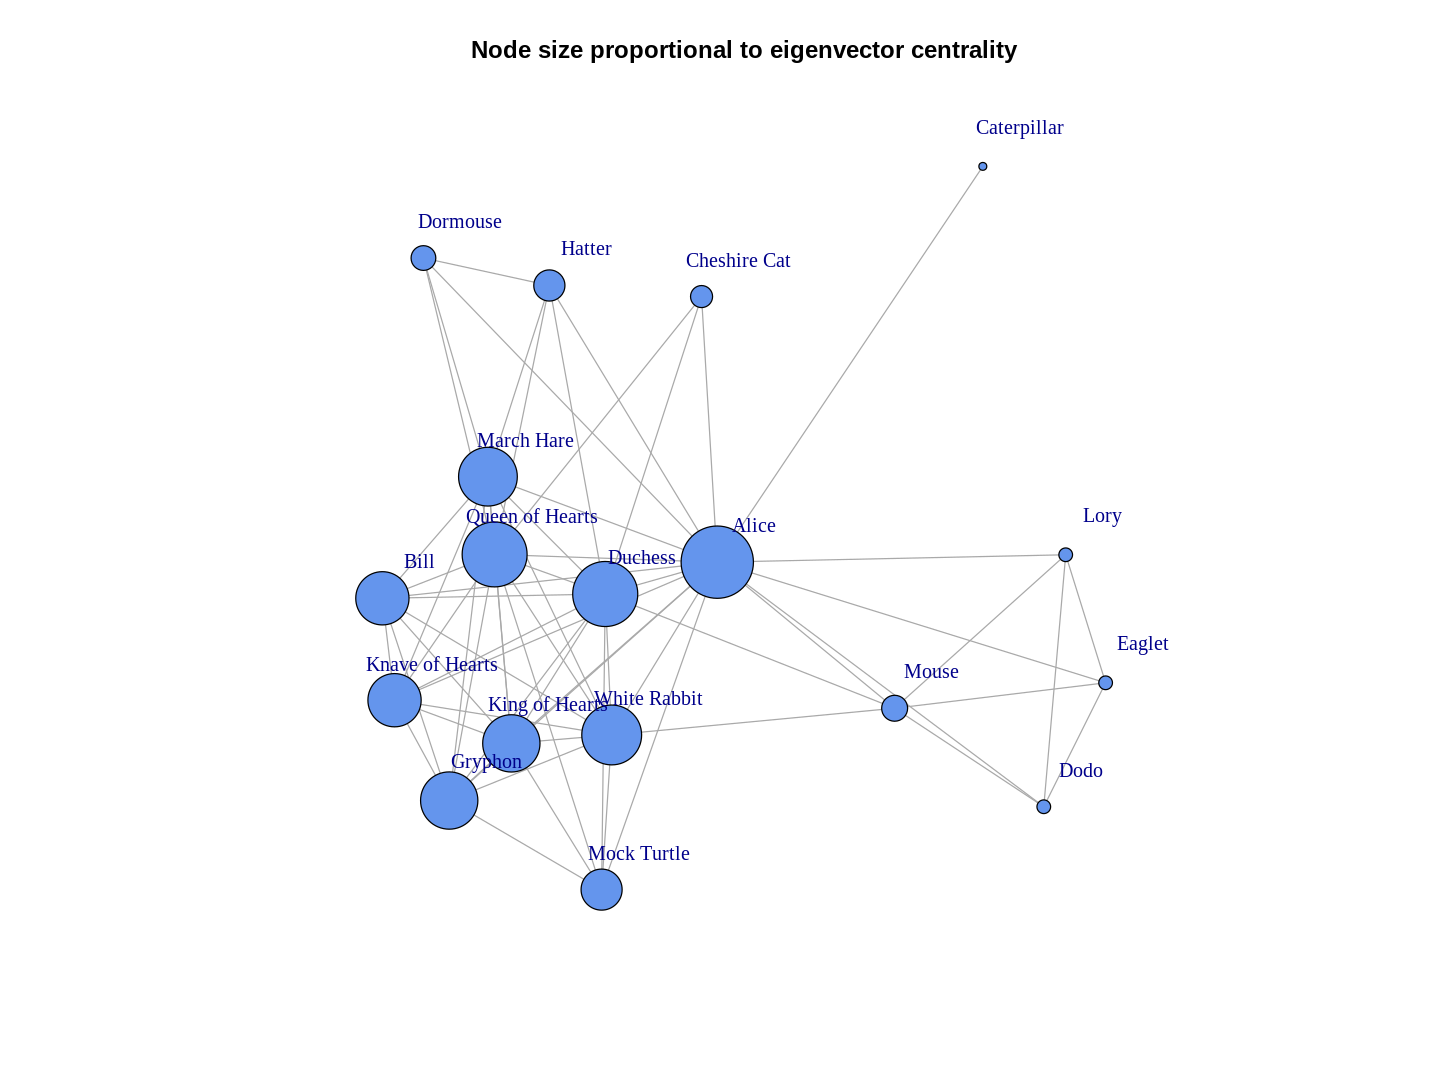

In [ ]:
# ---- Plot node size proportional to eigenvector centrality ----

par(mfrow = c(1, 1))

plot(
  character_network_thresholded,
  vertex.size = eigenvector_values * 20,
  vertex.color = "cornflowerblue",
  vertex.label.dist = 2,
  layout = igraph::layout_nicely,
  main = "Node size proportional to eigenvector centrality"
)

Alice has the highest eigenvector centrality, followed by characters such as the Duchess, Bill, the Queen of Hearts, the White Rabbit, the King of Hearts, and the Gryphon.

This suggests that the most central part of the network is the later story-world around Alice and the court/croquet characters, rather than the more peripheral early animal group.


## Comparing centrality measures

Different centrality measures define importance in different ways.

- **Degree**: many connections
- **Strength**: repeated or strong connections
- **Betweenness**: connects different parts of the network
- **Closeness**: close to everyone overall
- **Eigenvector centrality**: connected to other central nodes

These measures can agree, but they do not have to. In this network, Alice is central across several measures. Other characters may stand out more on some measures than others.

**Interpretation question**

Do the same characters look important across the different centrality measures, or do different measures highlight different characters?

In this plot, node colour represents degree.

This gives a visual check for assortativity. If similarly coloured nodes tend to connect to one another, the network may be assortative by degree. If high-degree and low-degree nodes tend to connect to each other, the network may be disassortative.

In small networks, assortativity should be interpreted cautiously.

# 13. Community detection

Community detection algorithms try to find groups of nodes that are more connected to each other than to the rest of the network.

A **community** is a group of nodes with many connections inside the group and fewer connections to nodes outside the group.

Here, we compare three algorithms:

- Girvan-Newman, also called edge betweenness
- Louvain
- Walktrap

The Girvan-Newman method works by repeatedly removing edges that act like bridges between groups. These are edges with high edge betweenness: many shortest paths pass through them.

![Girvan-Newman edge removal]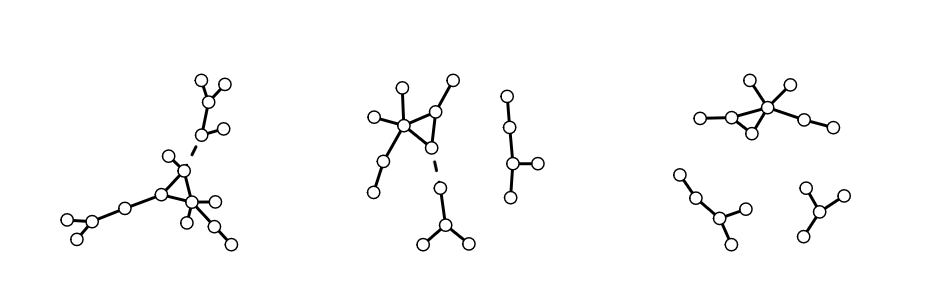

Each algorithm produces a modularity value, usually called *Q*. Modularity measures how clearly the network is divided into communities: higher values mean more connections within communities and fewer connections between communities.

Different algorithms may find different communities, so modularity is useful for comparison, but it should not be the only basis for interpretation.

In [ ]:
# ---- Community detection ----

# Reassign the network to a shorter name.
# This makes it easy to try different versions of the network.

gfcd <- character_network_thresholded

# Optional: try a different threshold
# gfcd <- thresh_graph(character_network, 3)

# Optional: try a random graph for comparison
# gfcd <- igraph::sample_gnp(20, .1)


# Set a common layout for all community plots.
# This makes the plots easier to compare visually.

set.seed(123)
community_layout <- igraph::layout_with_fr(gfcd)


# Girvan-Newman, also called edge betweenness

communities_edge_betweenness <- igraph::cluster_edge_betweenness(gfcd)

# Modularity for Girvan-Newman
max(communities_edge_betweenness$modularity)


# Louvain

communities_louvain <- igraph::cluster_louvain(
  gfcd,
  weights = NA
)

# Modularity for Louvain
max(communities_louvain$modularity)


# Walktrap

communities_walktrap <- igraph::cluster_walktrap(gfcd)

# Modularity for Walktrap
max(communities_walktrap$modularity)

Warning message in igraph::cluster_edge_betweenness(gfcd):
“Membership vector will be selected based on the highest modularity score.
Source: community/edge_betweenness.c:503”


[1] 0.1424472

[1] 0.2009871

[1] 0.1479568

The three numbers above are modularity values.

Higher modularity suggests that the algorithm found a clearer division of the network into communities. Because the algorithms search for communities in different ways, they may produce different results.

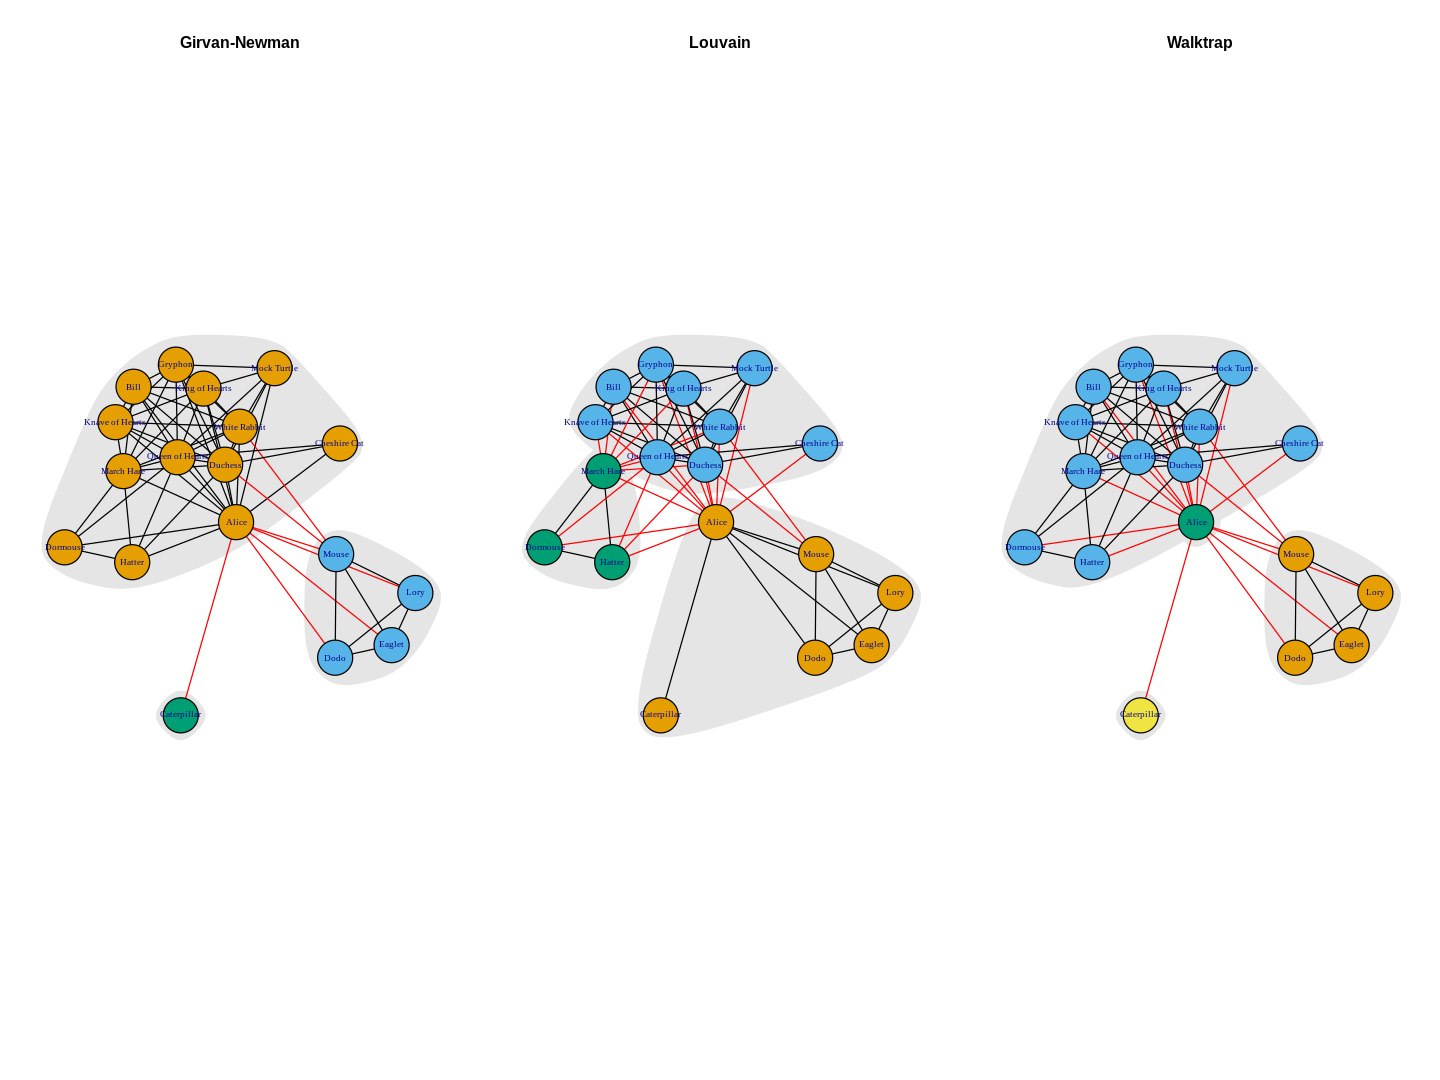

In [ ]:
# ---- Compare community detection algorithms visually ----

# Plot margins
par(mar = c(2, 2, 2, 2))

# Plot three panels side by side
par(mfrow = c(1, 3))

# Set node size for all plots
node_size <- 20

# Tuning parameter for title position
title_line <- -1


# Girvan-Newman

plot(
  communities_edge_betweenness,
  gfcd,
  mark.border = "gray90",
  mark.col = "gray90",
  vertex.label.cex = 0.7,
  vertex.size = node_size,
  layout = community_layout
)

title("Girvan-Newman", line = title_line)


# Louvain

plot(
  communities_louvain,
  gfcd,
  mark.border = "gray90",
  mark.col = "gray90",
  vertex.label.cex = 0.7,
  vertex.size = node_size,
  layout = community_layout
)

title("Louvain", line = title_line)


# Walktrap

plot(
  communities_walktrap,
  gfcd,
  mark.border = "gray90",
  mark.col = "gray90",
  vertex.label.cex = 0.7,
  vertex.size = node_size,
  layout = community_layout
)

title("Walktrap", line = title_line)


# Return to one plot per window
par(mfrow = c(1, 1))

# 14. Comparing the observed network to a random network

We can compare the observed Alice character network to a random network with the same number of nodes and edges.

This is useful because visual patterns in networks can sometimes look meaningful even when they are produced by chance. A random graph gives us a baseline: it asks what kind of structure we might see if the same number of characters and connections were arranged randomly.

If the observed network has more clustering, clearer communities, or a more interpretable structure than the random graph, this suggests that the co-appearance network contains non-random structure.

In [ ]:
# ---- Observed network at threshold 2 ----

# We use the thresholded Alice network from the previous step.
# This should already be based on threshold_value <- 2.

observed_network <- character_network_thresholded

# Number of nodes
observed_n <- igraph::vcount(observed_network)

# Number of edges
observed_m <- igraph::ecount(observed_network)

observed_n
observed_m

[1] 18

[1] 66

In [ ]:
# ---- Create random network with same number of nodes and edges ----

set.seed(123)

random_network <- igraph::sample_gnm(
  n = observed_n,
  m = observed_m,
  directed = FALSE,
  loops = FALSE
)

random_network

IGRAPH 18d756d U--- 18 66 -- Erdos-Renyi (gnm) graph
+ attr: name (g/c), type (g/c), loops (g/l), m (g/n)
+ edges from 18d756d:
 [1]  1-- 2  2-- 3  1-- 4  2-- 4  1-- 6  3-- 6  4-- 6  1-- 7  3-- 7  4-- 7
[11]  6-- 7  1-- 8  3-- 8  1-- 9  2-- 9  5-- 9  3--10  5--10  6--10  7--10
[21]  8--10  9--10  1--11  2--11  3--11  5--11  7--11 10--11  4--12  5--12
[31]  6--12  7--12  8--12  5--13  7--13  8--13 12--13  3--14  6--14 10--14
[41] 12--14  1--15  3--15  7--15 11--15 14--15  2--16  5--16  6--16 12--16
[51] 14--16 15--16  4--17  5--17  8--17 12--17 13--17 14--17 16--17  1--18
[61]  6--18  8--18 11--18 12--18 14--18 17--18

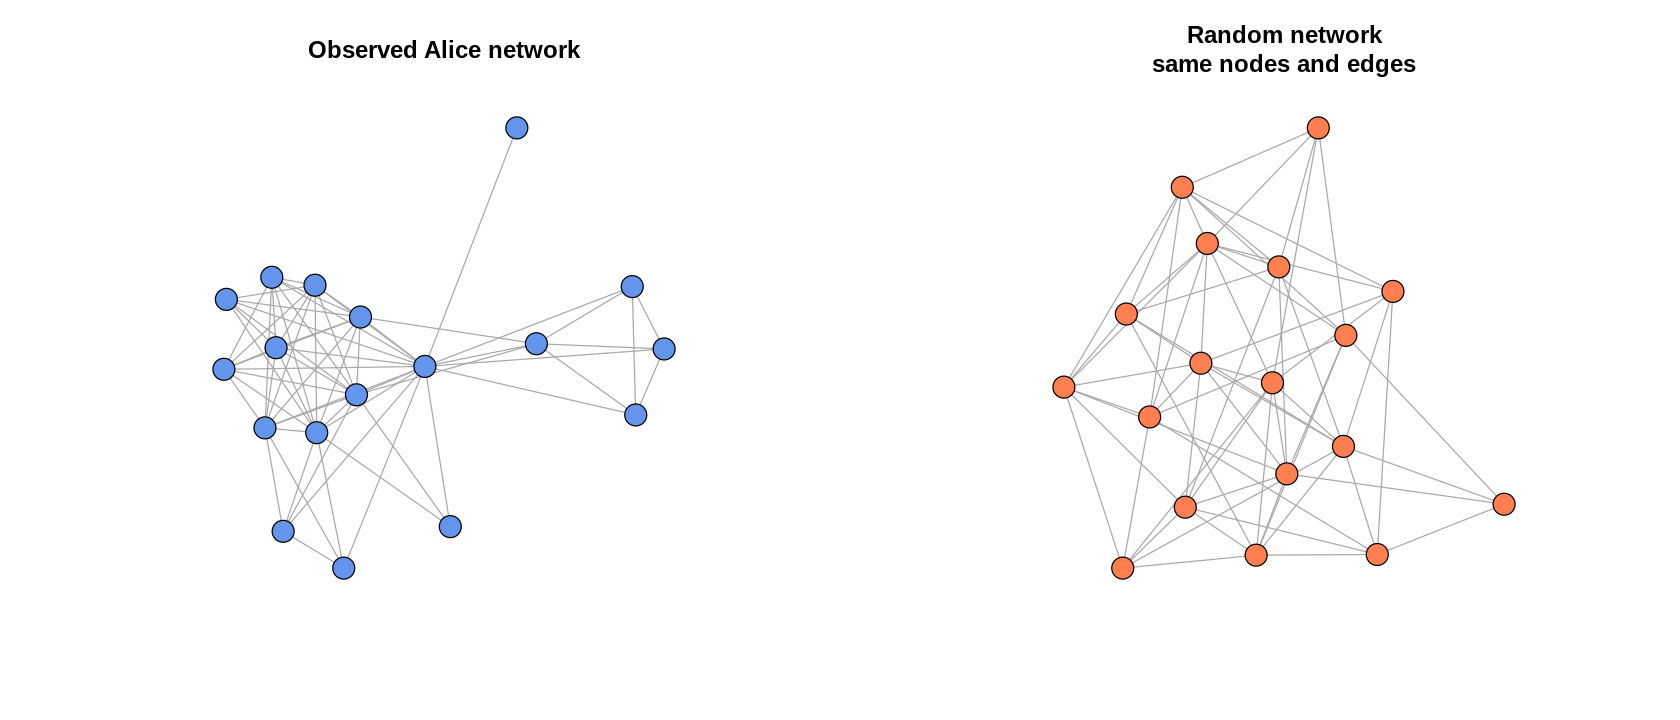

In [ ]:
# ---- Plot observed and random networks ----

options(repr.plot.width = 14, repr.plot.height = 6)

par(mfrow = c(1, 2))

plot(
  observed_network,
  vertex.label = NA,
  vertex.color = "cornflowerblue",
  vertex.size = 10,
  layout = igraph::layout_nicely,
  main = "Observed Alice network"
)

plot(
  random_network,
  vertex.label = NA,
  vertex.color = "coral",
  vertex.size = 10,
  layout = igraph::layout_nicely,
  main = "Random network\nsame nodes and edges"
)

par(mfrow = c(1, 1))

The two networks have the same number of nodes and edges.

The difference is that the Alice network is based on character co-appearances in the text, while the random network places the same number of edges at random.

This comparison helps us ask whether the observed network has structure beyond what we might expect from chance.

# 15. Additional Intepretattive quesitons and optional extension

If you have reached this point, use the results to interpret the Alice network.

These questions are designed to focus on the clearest and most interesting patterns from the analysis.

1. **Alice as a central node**  
   Alice is expected to be highly central because she appears across most of the story.  
   Which measures show this most clearly: degree, strength, betweenness, closeness, or eigenvector centrality?

2. **Co-occurrence versus identity**  
   Some animals, such as the Mouse, Dodo, Lory, and Eaglet, may cluster together. The Caterpillar may not cluster with them.  
   What does this tell us about what the network is detecting? Is it grouping characters by what they *are*, or by where they appear in the text?

3. **Narrative episodes as communities**  
   Do the communities look like parts of the story, such as the early animal scenes, the tea party, or the royal/court scenes?  
   What does this suggest about using co-occurrence networks to infer groups?

4. **Threshold choice**  
   We used a threshold of 2, meaning that two characters must appear together in at least two chapters to remain connected.  
   What changes when the threshold is lower or higher? Does the network become too crowded, too sparse, or easier to interpret?

5. **Observed versus random network**  
   Compare the observed Alice network to the Erdős-Rényi random network with the same number of nodes and edges.  
   Does the Alice network look more structured than the random network? Which evidence supports your answer: clustering, components, communities, or visual structure?

6. **Limits of interpretation**  
   The network connects characters who appear in the same chapter.  
   Does this necessarily mean the characters interact, speak, or have a social relationship? What would we need to change if we wanted a stricter social network?

## Finished early?

If you have answered these questions, you can either help others around you or try applying the same workflow to another text.

Several additional Project Gutenberg texts are available in the same GitHub data folder:

- `adventures_of_sherlock_holmes.txt`
- `pride_and_prejudice.txt`
- `romeo_and_juliet.txt`
- `the_count_of_monte_cristo.txt`

To analyse a different text, change the file name in the text-loading line.

`
alice_url <- "https://raw.githubusercontent.com/ant-jan/text-networks-workshop-26/main/data/raw/alice_in_wonderland.txt"`

*Note:

Changing the text file is only the first step.

Different books structure their text differently. You may need to adjust:

- the preprocessing step that removes the Project Gutenberg header and footer,
- the code that splits the text into chapters, acts, scenes, or stories,
- the character dictionary,
- the threshold value.

For example, *Romeo and Juliet* is organised by acts and scenes rather than chapters. *The Adventures of Sherlock Holmes* is a collection of short stories. These differences affect how co-occurrence should be defined.